## Predicción del riesgo de retraso en vuelos a partir del itinerario programado
Análisis exploratorio - EDA

**Autora:** Katherin Rodríguez

El equipo ya cubrió la caracterización descriptiva del dataset (estructura, nulos, balance de clases, tasas por aerolínea y por día). Esta exploración parte de ahí y se concentra en **tres preguntas que quedaron abiertas** y que condicionan directamente la fase de modelado:

1. Los 216.618 duplicados exactos, ¿son un error de carga o vuelos recurrentes? Se   dejó documentado como pendiente por no existir una columna de fecha.
2. Si no hay fecha, ¿de verdad no hay información temporal en el dataset?
3. ¿La aerolínea predice el retraso por sí misma, o solo está capturando el efecto de la hora   a la que programa sus vuelos?
   La respuesta a las dos primeras cambia la forma en que se debe particionar el dataset paraentrenar y evaluar, así que se resuelven antes de proponer cualquier modelo.

### 1. Carga de los datos

Primera observación de calidad: el CSV proviene de la sección `@data` de un archivo ARFF y conserva un **espacio después de cada coma**. Al leerlo con `pd.read_csv` sin más, los 539.383 valores de `AirportFrom` y `AirportTo` quedan con un espacio inicial (`' SFO'` en vez de `'SFO'`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RUTA = "../data/airlines.csv"

crudo = pd.read_csv(RUTA)
print("Sin limpiar :", [repr(v) for v in crudo["AirportFrom"].head(3)])
print("Filas afectadas:", int(crudo["AirportFrom"].str.startswith(" ").sum()), "de", len(crudo))

Sin limpiar : ["' SFO'", "' PHX'", "' LAX'"]
Filas afectadas: 539383 de 539383


El espacio es uniforme, así que no altera la cardinalidad (293 aeropuertos en ambos casos) ni invalida los análisis. Pero sí rompería cualquier cruce posterior con un catálogo externo de aeropuertos, así que se corrige en la lectura con `skipinitialspace=True`.

In [2]:
airlines = pd.read_csv(RUTA, skipinitialspace=True)
print("Limpio      :", [repr(v) for v in airlines["AirportFrom"].head(3)])
print("Aeropuertos origen distintos:", airlines["AirportFrom"].nunique())
airlines.head()

Limpio      : ["'SFO'", "'PHX'", "'LAX'"]
Aeropuertos origen distintos: 293


,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0


## 2. Verificación de calidad

Se confirman los rangos y los cuatro registros con duración inválida.

In [3]:
chequeos = pd.Series({
    "Filas": len(airlines),
    "Nulos totales": int(airlines.isna().sum().sum()),
    "Duplicados exactos": int(airlines.duplicated().sum()),
    "Length <= 0": int((airlines["Length"] <= 0).sum()),
    "Time fuera de 0-1439": int((~airlines["Time"].between(0, 1439)).sum()),
    "DayOfWeek fuera de 1-7": int((~airlines["DayOfWeek"].between(1, 7)).sum()),
    "Origen igual a destino": int((airlines["AirportFrom"] == airlines["AirportTo"]).sum()),
}, name="Registros")
chequeos.to_frame()

,Registros
Filas,539383
Nulos totales,0
Duplicados exactos,216618
Length <= 0,4
Time fuera de 0-1439,0
DayOfWeek fuera de 1-7,0
Origen igual a destino,0


In [4]:
airlines[airlines["Length"] == 0]

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
179149,F9,106,DEN,MSP,6,635,0,0
182840,F9,107,MSP,DEN,6,851,0,0
188953,F9,103,MSP,DEN,7,375,0,0
445578,B6,493,BOS,SEA,7,1060,0,1


Los cuatro registros son inválidos por definición: un `BOS-SEA` de JetBlue no puede durar 0 minutos. Son 4 de 539.383 filas (0,0007%), así que se eliminan en la limpieza sin discusión.

## 3. Los duplicados: ¿error de carga o vuelos recurrentes?

Se encontró 216.618 filas exactamente repetidas (40,2%) y no se eliminaron por no poder descartar que fueran vuelos recurrentes. La pregunta se puede resolver con los datos que hay. 
La idea: separar la **clave de itinerario** (aerolínea, número de vuelo, origen, destino, día dela semana, hora y duración) de la variable objetivo. 
Si dos filas comparten itinerario pero tienen `Delay` distinto, **no pueden ser copias del mismo registro**: son dos observaciones distintas del mismo vuelo programado.

In [5]:
ITINERARIO = ["Airline", "Flight", "AirportFrom", "AirportTo", "DayOfWeek", "Time", "Length"]

grupos = airlines.groupby(ITINERARIO, sort=False)["Delay"]
tam = grupos.size()
distintos = grupos.nunique()

repetidos = tam[tam > 1]
contradictorios = tam[(tam > 1) & (distintos > 1)]

resumen = pd.Series({
    "Claves de itinerario distintas": grupos.ngroups,
    "Claves que aparecen mas de una vez": len(repetidos),
    "De esas, con Delay contradictorio": len(contradictorios),
}, name="Conteo")
print(resumen.to_frame().to_string())
print()
print(f"Porcentaje de itinerarios repetidos con Delay contradictorio: "
      f"{len(contradictorios) / len(repetidos):.2%}")

                                    Conteo
Claves de itinerario distintas      227392
Claves que aparecen mas de una vez  185451
De esas, con Delay contradictorio    95373

Porcentaje de itinerarios repetidos con Delay contradictorio: 51.43%


**El 51,4% de los itinerarios que se repiten aparece con `Delay` 0 y 1 a la vez.** Un error de carga que duplicara filas produciría copias idénticas, nunca resultados opuestos para el mismo vuelo. Por lo tanto los registros repetidos corresponden a **ocurrencias distintas del mismo vuelo programado**, y eliminarlos borraría observaciones reales.

Queda por explicar qué distingue una ocurrencia de otra, ya que no hay columna de fecha.

## 4. El dataset sí tiene orden temporal

El dataset original es un *benchmark* de *concept drift* del Data Expo 2009, lo que sugiere quelas filas están ordenadas en el tiempo. Se puede verificar sin necesidad de una fecha: basta mirar cómo se comporta `DayOfWeek` a lo largo del archivo.

In [6]:
dia_semana = airlines["DayOfWeek"].to_numpy()
cambios = np.flatnonzero(dia_semana[1:] != dia_semana[:-1]) + 1

bloques = dia_semana[np.concatenate(([0], cambios))]
print("Numero de bloques consecutivos de un mismo dia:", len(bloques))
print("Secuencia de dias en el orden del archivo:")
print(bloques.tolist())

Numero de bloques consecutivos de un mismo dia: 31
Secuencia de dias en el orden del archivo:
[3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5]


`DayOfWeek` no se alterna al azar: forma **31 bloques consecutivos** que recorren la semana en orden (3, 4, 5, 6, 7, 1, 2, 3, ...). El archivo son 31 días calendario seguidos, empezando un miércoles. Y dentro de cada bloque, la hora programada solo crece.

In [7]:
fin_primer_dia = cambios[0]
primer_dia = airlines["Time"].iloc[:fin_primer_dia]
print(f"Primer dia: {fin_primer_dia} vuelos, Time de {primer_dia.min()} a {primer_dia.max()}")
print("Time es monotono no decreciente dentro del dia:", primer_dia.is_monotonic_increasing)

Primer dia: 17612 vuelos, Time de 15 a 1439
Time es monotono no decreciente dentro del dia: True


**El índice de la fila es una variable temporal**. Se reconstruye el día calendario como el número de bloque, lo que da una columna de fecha relativa que el dataset no traía.

In [8]:
indice_dia = np.zeros(len(airlines), dtype=int)
indice_dia[cambios] = 1
airlines["DiaCalendario"] = indice_dia.cumsum()

vuelos_por_dia = airlines.groupby("DiaCalendario").size()
print("Dias reconstruidos:", airlines["DiaCalendario"].nunique())
print(f"Vuelos por dia: min {vuelos_por_dia.min()}, max {vuelos_por_dia.max()}, "
      f"media {vuelos_por_dia.mean():.0f}")

Dias reconstruidos:

 31
Vuelos por dia: min 14279, max 18585, media 17399


Esto explica los duplicados: un vuelo semanal que opera todos los miércoles aparece hasta 4 o 5veces en el archivo, con las mismas 7 columnas de itinerario, y el `Delay` cambia según el día.

## 5. La tasa de retraso se desplaza a lo largo del mes

Con el día reconstruido se puede medir algo que ningún análisis podía ver: cómo evoluciona la variable objetivo en el tiempo.

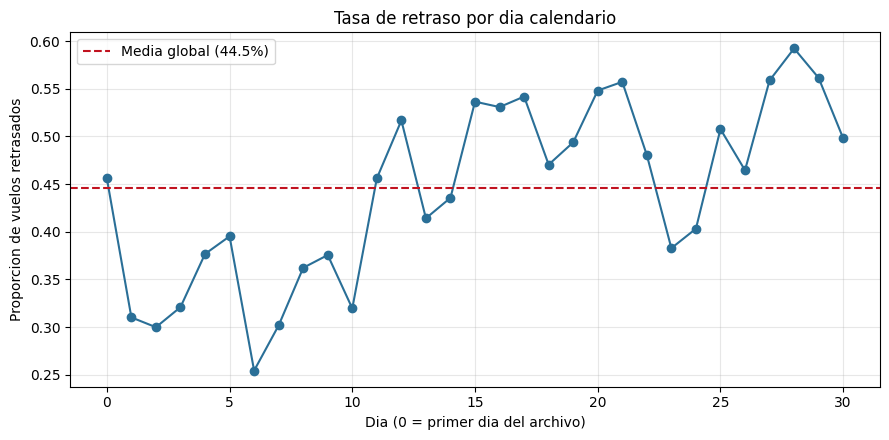

Dia con menos retrasos: 6 (25.4%)
Dia con mas retrasos  : 28 (59.2%)
Primeros 7 dias: 34.53%
Ultimos 7 dias : 51.63%


In [9]:
tasa_por_dia = airlines.groupby("DiaCalendario")["Delay"].mean()

fig, ax = plt.subplots()
ax.plot(tasa_por_dia.index, tasa_por_dia.values, marker="o", color="#2A6F97")
ax.axhline(airlines["Delay"].mean(), color="#C1121F", linestyle="--",
           label=f"Media global ({airlines['Delay'].mean():.1%})")
ax.set(title="Tasa de retraso por dia calendario",
       xlabel="Dia (0 = primer dia del archivo)", ylabel="Proporcion de vuelos retrasados")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Dia con menos retrasos: {tasa_por_dia.idxmin()} ({tasa_por_dia.min():.1%})")
print(f"Dia con mas retrasos  : {tasa_por_dia.idxmax()} ({tasa_por_dia.max():.1%})")
print(f"Primeros 7 dias: {airlines[airlines.DiaCalendario < 7]['Delay'].mean():.2%}")
print(f"Ultimos 7 dias : {airlines[airlines.DiaCalendario >= 24]['Delay'].mean():.2%}")

La tasa pasa de **34,5% en la primera semana a 51,6% en la última**, con días extremos de 25,4%y 59,2%. Esta deriva es mucho más grande que cualquiera de los efectos que se midió (el día de la semana movía la tasa entre 40% y 47%).

Es decir: **el momento del mes explica más varianza que `DayOfWeek`**, y el balance global de 55,5% / 44,5% que reportamos es un promedio de dos regímenes bastante distintos.

## 6. Consecuencia práctica: la partición no puede ser aleatoria

Si la tasa base cambia en el tiempo, una partición aleatoria reparte los mismos días entre entrenamiento y prueba, y el modelo evalúa sobre un período que ya conoce. 

La partición correcta es temporal: entrenar con los primeros días y evaluar con los últimos.El costo de ignorarlo se puede cuantificar. Con una partición temporal (días 0-24 para entrenamiento, 25-30 para prueba), la clase mayoritaria del entrenamiento **ni siquiera es la clase mayoritaria de la prueba**.

In [10]:
CORTE = 25
entrena = airlines[airlines["DiaCalendario"] < CORTE]
prueba = airlines[airlines["DiaCalendario"] >= CORTE]

mayoritaria = int(entrena["Delay"].mean() >= 0.5)

print(f"Entrenamiento: {len(entrena):,} filas | tasa de retraso {entrena['Delay'].mean():.2%}")
print(f"Prueba       : {len(prueba):,} filas | tasa de retraso {prueba['Delay'].mean():.2%}")
print()
print(f"Clase mayoritaria aprendida en entrenamiento: {mayoritaria}")
print(f"Accuracy de predecir siempre esa clase en prueba: "
      f"{(prueba['Delay'] == mayoritaria).mean():.2%}")

Entrenamiento: 431,918 filas | tasa de retraso 42.41%
Prueba       : 107,465 filas | tasa de retraso 53.14%

Clase mayoritaria aprendida en entrenamiento: 0
Accuracy de predecir siempre esa clase en prueba: 46.86%


El clasificador trivial obtiene **46,9%**, peor que lanzar una moneda, porque aprendió que la clase dominante era "sin retraso" (42,4% de retrasos) y en el período de prueba la mayoría devuelos sí se retrasa (53,1%). Una partición aleatoria habría escondido por completo esteproblema.

## 7. Líneas base que el modelo tendrá que superar

Antes de entrenar nada conviene fijar el piso. Se prueban dos referencias sobre la misma partición temporal.

In [11]:
# Linea base 1: memorizar el resultado historico de cada itinerario.
historico = entrena.groupby(ITINERARIO, sort=False)["Delay"].mean()
claves_prueba = pd.MultiIndex.from_frame(prueba[ITINERARIO])
emparejado = historico.reindex(claves_prueba)

conocido = emparejado.notna().to_numpy()
pred_memoria = np.where(conocido, (emparejado.to_numpy() >= 0.5), bool(mayoritaria)).astype(int)
real = prueba["Delay"].to_numpy()

print(f"Cobertura (itinerarios de prueba vistos en entrenamiento): {conocido.mean():.2%}")
print(f"Accuracy global                        : {(pred_memoria == real).mean():.2%}")
print(f"Accuracy solo en itinerarios conocidos : {(pred_memoria[conocido] == real[conocido]).mean():.2%}")

Cobertura (itinerarios de prueba vistos en entrenamiento): 83.68%
Accuracy global                        : 55.41%
Accuracy solo en itinerarios conocidos : 59.70%


In [12]:
# Linea base 2: tasa historica por aerolinea y franja horaria.
franjas = pd.cut(airlines["Time"], bins=[0, 360, 720, 1080, 1440],
                 labels=["00-06", "06-12", "12-18", "18-24"], right=False)
airlines["Franja"] = franjas

entrena = airlines[airlines["DiaCalendario"] < CORTE]
prueba = airlines[airlines["DiaCalendario"] >= CORTE]

tabla = entrena.groupby(["Airline", "Franja"], observed=True)["Delay"].mean()
emparejado2 = tabla.reindex(pd.MultiIndex.from_frame(prueba[["Airline", "Franja"]]))
pred_tabla = np.where(emparejado2.isna(), bool(mayoritaria),
                      emparejado2.to_numpy() >= 0.5).astype(int)

print(f"Accuracy aerolinea x franja horaria: {(pred_tabla == prueba['Delay'].to_numpy()).mean():.2%}")

Accuracy aerolinea x franja horaria: 59.76%


| Línea base | Accuracy en prueba |
|---|---|
| Siempre la clase mayoritaria | 46,9% |
| Memorizar el itinerario | 55,4% |
| Tasa histórica por aerolínea × franja | 59,8% |

**Cualquier modelo del proyecto debe superar el 59,8%** para justificar su complejidad. Es un umbral mucho más exigente que el 55,5% de la clase mayoritaria global que sugeriría el balance de clases, y conviene reportarlo desde la entrega de modelos.

## 8. ¿La aerolínea o la hora?

`WN` tiene 69,8% de retrasos y `Time` correlaciona positivamente con `Delay`. Cabe la hipótesisde que WN se vea mal simplemente porque programa más tarde. Se contrasta.

In [13]:
por_aerolinea = airlines.groupby("Airline").agg(
    Vuelos=("Delay", "size"),
    Tasa=("Delay", "mean"),
    HoraMedia=("Time", "mean"),
).sort_values("Tasa", ascending=False)

print(por_aerolinea.to_string(float_format=lambda v: f"{v:.3f}"))
print()
print("Correlacion entre tasa de retraso y hora media de la aerolinea:",
      round(por_aerolinea["Tasa"].corr(por_aerolinea["HoraMedia"]), 3))

         Vuelos  Tasa  HoraMedia
Airline                         
WN        94097 0.698    802.344
CO        21118 0.566    790.355
B6        18112 0.467    825.502
OO        50254 0.453    811.207
DL        60940 0.450    799.636
F9         6456 0.449    807.089
EV        27983 0.402    799.840
9E        20686 0.398    792.173
AA        45656 0.388    800.803
XE        31126 0.379    792.137
MQ        36605 0.348    791.475
AS        11471 0.339    796.656
US        34500 0.336    805.076
UA        27619 0.324    797.745
HA         5578 0.320    795.226
FL        20827 0.301    833.154
OH        12630 0.277    793.021
YV        13725 0.243    832.257

Correlacion entre tasa de retraso y hora media de la aerolinea: -0.179


La correlación es **-0,18**: negativa, no positiva. Las aerolíneas que programan más tarde no son las que más se retrasan; de hecho `FL` y `YV`, las dos de hora media más tardía (833 y 832minutos), están entre las de menor tasa. La hora media de WN (802) es prácticamente la media del dataset (803). La comparación directa dentro de cada franja horaria lo confirma.

        mean             size          
Grupo  Resto    WN      Resto        WN
Franja                                 
00-06  0.279   NaN   6176.000       NaN
06-12  0.319 0.567 179224.000 39225.000
12-18  0.441 0.780 170337.000 36593.000
18-24  0.453 0.813  89549.000 18279.000


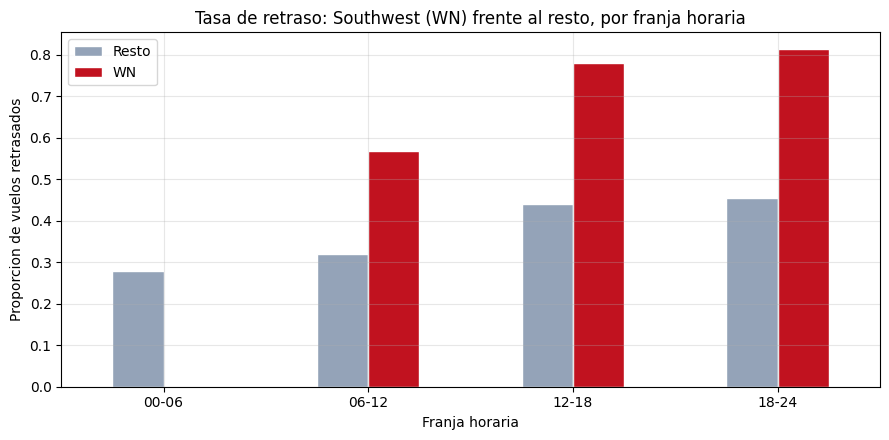

In [14]:
grupo = np.where(airlines["Airline"] == "WN", "WN", "Resto")
comparacion = (airlines.assign(Grupo=grupo)
               .groupby(["Franja", "Grupo"], observed=True)["Delay"]
               .agg(["mean", "size"]).unstack())

tasas = comparacion["mean"]
print(comparacion.to_string(float_format=lambda v: f"{v:.3f}"))

ax = tasas.plot(kind="bar", color=["#94A3B8", "#C1121F"], edgecolor="white")
ax.set(title="Tasa de retraso: Southwest (WN) frente al resto, por franja horaria",
       xlabel="Franja horaria", ylabel="Proporcion de vuelos retrasados")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

En cada franja WN casi duplica al resto: 56,7% frente a 31,9% en la mañana, 78,0% frente a 44,1%en la tarde y 81,3% frente a 45,3% en la noche. **El efecto de la aerolínea es real y no está explicado por la hora.** WN además no opera ningún vuelo en la franja 00-06.

Conclusión para el modelado: `Airline` y `Time` aportan información distinta y ambas deben entrar al modelo; no son redundantes.

## 9. Rutas

Ningún análisis previo miró el par origen-destino como unidad. Es la agregación natural del problema y resulta más discriminante que los aeropuertos por separado.

In [15]:
airlines["Ruta"] = airlines["AirportFrom"] + "-" + airlines["AirportTo"]

rutas = airlines.groupby("Ruta")["Delay"].agg(Vuelos="size", Tasa="mean")
frecuentes = rutas[rutas["Vuelos"] >= 500].sort_values("Tasa", ascending=False)

print("Rutas distintas:", airlines["Ruta"].nunique())
print("Rutas con al menos 500 vuelos:", len(frecuentes))
print(f"Rango de tasa entre rutas frecuentes: {frecuentes['Tasa'].min():.1%} a {frecuentes['Tasa'].max():.1%}")

Rutas distintas: 4190
Rutas con al menos 500 vuelos: 99
Rango de tasa entre rutas frecuentes: 19.0% a 68.0%


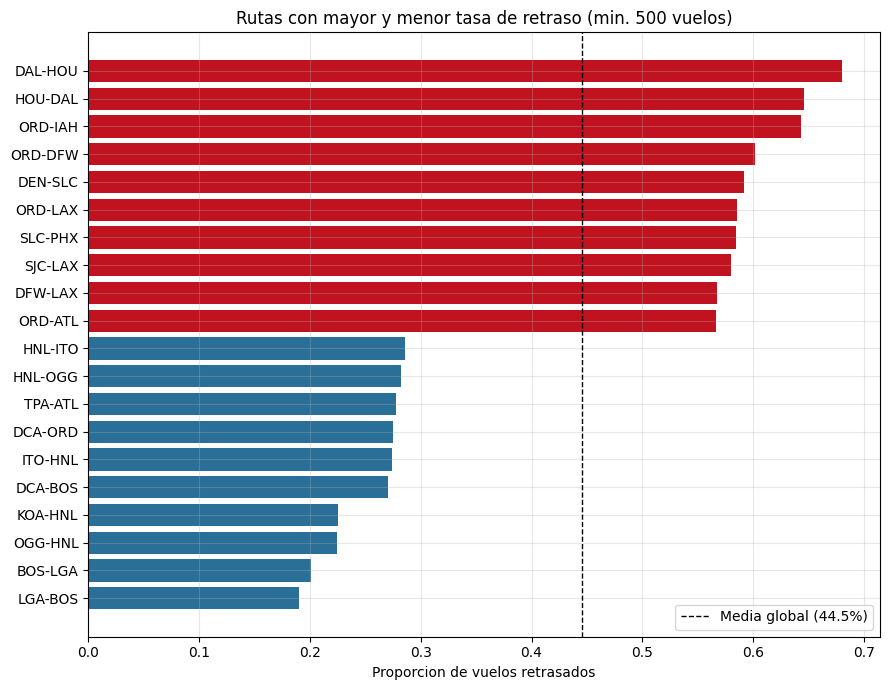

In [16]:
extremos = pd.concat([frecuentes.head(10), frecuentes.tail(10)])

fig, ax = plt.subplots(figsize=(9, 7))
colores = ["#C1121F"] * 10 + ["#2A6F97"] * 10
ax.barh(extremos.index[::-1], extremos["Tasa"].to_numpy()[::-1], color=colores[::-1])
ax.axvline(airlines["Delay"].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Media global ({airlines['Delay'].mean():.1%})")
ax.set(title="Rutas con mayor y menor tasa de retraso (min. 500 vuelos)",
       xlabel="Proporcion de vuelos retrasados")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Quien opera los extremos
for ruta in ["DAL-HOU", "HOU-DAL", "LGA-BOS", "OGG-HNL"]:
    sub = airlines[airlines["Ruta"] == ruta]
    reparto = sub["Airline"].value_counts(normalize=True).head(3)
    detalle = ", ".join(f"{a} {p:.0%}" for a, p in reparto.items())
    print(f"{ruta}: {len(sub):>4} vuelos | tasa {sub['Delay'].mean():.1%} | {detalle}")

DAL-HOU:  701 vuelos | tasa 68.0% | WN 100%
HOU-DAL:  698 vuelos | tasa 64.6% | WN 100%
LGA-BOS:  795 vuelos | tasa 19.0% | US 39%, DL 37%, MQ 24%


OGG-HNL:  982 vuelos | tasa 22.4% | HA 78%, YV 22%


Las dos peores rutas del dataset, `DAL-HOU` y `HOU-DAL` (68,0% y 64,6%), son **100% Southwest**, es su puente aéreo entre Dallas Love Field y Houston Hobby. 

El efecto de ruta y el de aerolínea son en buena parte el mismo efecto, así que meter ambas variables sin control introduciría colinealidad.

En el otro extremo, `LGA-BOS` (19,0%) se reparte entre tres aerolíneas y `OGG-HNL` (22,4%) es sobre todo Hawaiian, trayectos cortos y de alta frecuencia, con menos exposición a la propagación de retrasos.

## Conclusiones e implicaciones para el modelado

**Sobre los datos**


1. El CSV arrastra un espacio inicial en `AirportFrom` y `AirportTo` en las 539.383 filas. No   afecta los conteos, pero debe corregirse con `skipinitialspace=True` antes de cruzar con   fuentes externas.
   
2. Los 4 registros con `Length = 0` son inválidos y se eliminan.
   
3. **Los 216.618 duplicados exactos no son un error de carga.** El 51,4% de los itinerarios   repetidos aparece con `Delay` contradictorio, lo que solo es posible si son ocurrencias   distintas del mismo vuelo programado. **No deben eliminarse.**
   
4. **El dataset sí tiene estructura temporal**: las filas están ordenadas cronológicamente en 31   días consecutivos, y dentro de cada día `Time` es creciente. El índice de la fila es una   variable temporal utilizable, y permite reconstruir el día calendario que faltaba.
   
**Sobre el modelado**

5. La tasa de retraso se desplaza de 34,5% a 51,6% entre la primera y la última semana. La   partición **debe ser temporal**; una aleatoria mezcla regímenes y sobreestima el desempeño.
   
6. Con partición temporal, predecir siempre la clase mayoritaria da 46,9%, por debajo del azar.   El piso real a superar es **59,8%**, el de la tasa histórica por aerolínea × franja horaria.
   
7. `Airline` no es un sustituto de `Time`: la correlación entre la tasa de una aerolínea y su   hora media es -0,18, y WN casi duplica al resto dentro de cada franja. Ambas variables entran.
   
8. `Ruta` (origen-destino) discrimina entre 19,0% y 68,0% en rutas frecuentes, pero se solapa con   `Airline` en los extremos; conviene evaluar su aporte incremental antes de incluirla.
   
9.  `Flight` es un identificador, no una magnitud. Su correlación de -0,34 con `Length` es un   artefacto de cómo las aerolíneas numeran sus vuelos y no debe usarse como variable numérica.